# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [1]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, val_loader, test_loader= dataset.get_train_val_test_loader(
    history=10,
    future=4,
    batch_size=64
)

Train samples: 15295
Validation samples: 1657
Test samples: 4332
Mean: 1.6131, Std: 1.7061


## Deep Transformer Model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import random
import numpy as np
import matplotlib.pyplot as plt
import copy



class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to each token's features so that
    the Transformer is position-aware.

    Reference: Vaswani et al. 2017, Section 3.5
      PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
      PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model: int, max_len: int = 1000):
        super(PositionalEncoding, self).__init__()

        ###########################################################################
        # Pre-compute the sinusoidal encoding matrix and register
        # it as a buffer of shape [1, max_len, d_model].
        ###########################################################################

        pe = torch.zeros(max_len, d_model)              # [max_len, d_model]
        position = torch.arange(0, max_len).unsqueeze(1) # [max_len, 1]

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, D]
        returns: [B, T, D] with positional encoding added.
        """
        ###########################################################################
        # Add the positional encoding to x.
        ###########################################################################
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class DeepTransformer(nn.Module):
    def __init__(self, input_dim: int = 1, output_dim: int = 1, d_model: int = 64, num_heads: int = 4,
                 ff_dim: int = 256, encoder_layers: int = 4, decoder_layers: int = 4,
                 dropout: float = 0.2):
        super(DeepTransformer, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.position_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=encoder_layers
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=decoder_layers
        )

        self.output_proj = nn.Linear(d_model, output_dim)

    def generate_square_subsequent_mask(self, T, device):
        """
        upper triangle matrix:
          0  -inf -inf -inf
          0    0  -inf -inf
          0    0    0  -inf
          0    0    0    0
        """
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, src, tgt):
        """
        src: [B, src_len, input_dim]
             example: x1...x10

        tgt: [B, tgt_len, input_dim]
             example: x10...x13

        return: [B, tgt_len, output_dim]
             example: predict x11...x14
        """
        src = self.input_proj(src)
        src = self.position_encoder(src)

        memory = self.encoder(src)  # self attention

        tgt = self.input_proj(tgt)
        tgt = self.position_encoder(tgt)

        tgt_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_len, tgt.device)

        out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)

        return self.output_proj(out)

In [5]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f'Device: {self.device}')
        if torch.cuda.is_available():
            print(f'GPU: {torch.cuda.get_device_name(0)}')
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1.0,
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        self.loss_func = nn.MSELoss()

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for src, y in self.train_loader:
            src, y = src.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()

            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
    
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count
    
    @torch.no_grad()
    def predict_autoregressive(self, model, src, future=4):
        model.eval()
    
        # tgt starts from the last observed value x10
        tgt = src[:, -1:, :]
    
        preds = []
    
        for _ in range(future):
            out = model(src, tgt)
    
            # take the last predicted step
            next_pred = out[:, -1:, :]
    
            preds.append(next_pred)
    
            # append prediction back to tgt
            tgt = torch.cat([tgt, next_pred], dim=1)
    
        return torch.cat(preds, dim=1)

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for src, y in dataloader:
            src, y = src.to(self.device), y.to(self.device)
            
            tgt = torch.cat([src[:, -1:, :], y[:, :-1, :]], dim=1)
            
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
    
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count


    @torch.no_grad()
    def evaluate_metrics(self, model, dataloader, future=4):
        model.eval()
    
        all_preds = []
        all_targets = []
    
        for src, y in dataloader:
            src = src.to(self.device)
            y = y.to(self.device)
    
            pred = self.predict_autoregressive(model, src, future=future)
    
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())
    
        preds = torch.cat(all_preds, dim=0).numpy()
        targets = torch.cat(all_targets, dim=0).numpy()
    
        preds = preds.reshape(-1)
        targets = targets.reshape(-1)
    
        rmse = np.sqrt(mean_squared_error(targets, preds))
        
        corr, _ = pearsonr(targets, preds)
    
        return rmse, corr

### Training

In [4]:
transformer_model = DeepTransformer()

pipeline = PipeLine(model=transformer_model, train_loader=train_loader, val_loader=val_loader)

best_model, train_losses, val_losses = pipeline.train_model(200)

pipeline.evaluate_metrics(best_model, test_loader)

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Epoch   1/200 | Train Loss: 0.4589 | Val Loss: 0.1343
Epoch  10/200 | Train Loss: 0.1447 | Val Loss: 0.1228
Epoch  20/200 | Train Loss: 0.1401 | Val Loss: 0.1077
Epoch  30/200 | Train Loss: 0.1357 | Val Loss: 0.1126
Epoch  40/200 | Train Loss: 0.1327 | Val Loss: 0.1077
Epoch  50/200 | Train Loss: 0.1316 | Val Loss: 0.1083
Epoch  60/200 | Train Loss: 0.1294 | Val Loss: 0.1047
Epoch  70/200 | Train Loss: 0.1272 | Val Loss: 0.1047
Epoch  80/200 | Train Loss: 0.1275 | Val Loss: 0.1093
Epoch  90/200 | Train Loss: 0.1275 | Val Loss: 0.1121
Epoch 100/200 | Train Loss: 0.1261 | Val Loss: 0.1122
Epoch 110/200 | Train Loss: 0.1254 | Val Loss: 0.1095
Epoch 120/200 | Train Loss: 0.1254 | Val Loss: 0.1060
Epoch 130/200 | Train Loss: 0.1243 | Val Loss: 0.1068
Epoch 140/200 | Train Loss: 0.1251 | Val Loss: 0.1041
Epoch 150/200 | Train Loss: 0.1234 | Val Loss: 0.1062
Epoch 160/200 | Train Loss: 0.1232 | Val Loss: 0.1092
Epoch 170/200 | Train Loss

(np.float32(1.0911093), np.float32(0.8727643))

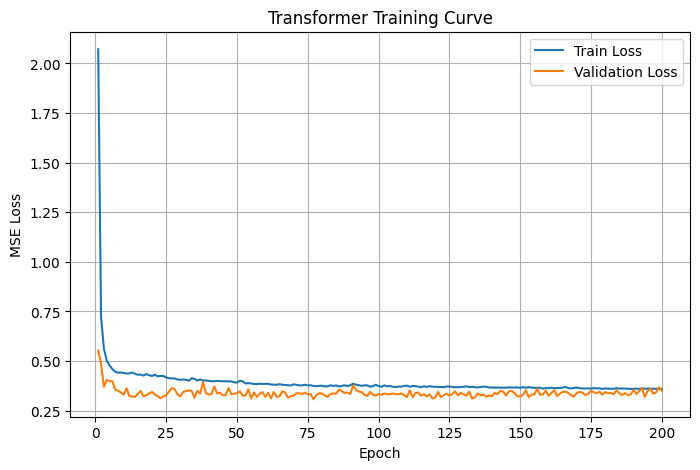

In [10]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training Curve")
plt.legend()
plt.grid(True)

plt.show()

# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case